# Executive Order Analysis

Analysis over `data/analysis.db`: 1,534 Executive Orders, EO 12890 (1993-12-30) to
EO 14423 (2026-08-28), extracted by `openai/gpt-oss-120b` under prompt v7 (run 11).

Before quoting any number from this notebook, read
[INVESTIGATORS_CHEAT_SHEET.md](../INVESTIGATORS_CHEAT_SHEET.md). The four things it
says most often:

- **Recall was never measured.** "The model extracted X from 66% of orders" is
  supportable; "34% of orders have no X" is not.
- **Count agencies through `agency_taskings`**, ranked by distinct orders, excluding
  `kind IN ('collective', 'generic')`.
- **Filter relationships to `authoritative = 1`** (the `revocation_network` view
  already does).
- **Only `source_quote` is verified.** `summary` and `task` are model prose.

Every cell runs from the repository root with the project venv:

```sh
pip install -e ".[analysis]"
PYTHONPATH=src .venv/bin/jupyter lab notebooks/analysis.ipynb
```

## Setup

In [1]:
import re
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from eo.grounding import is_grounded  # noqa: E402

DB = ROOT / "data" / "analysis.db"
con = sqlite3.connect(f"file:{DB}?mode=ro", uri=True)


def q(sql: str, **params) -> pd.DataFrame:
    """Run a query against analysis.db (read-only) and return a DataFrame."""
    return pd.read_sql_query(sql, con, params=params or None)


pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

# Presidents in chronological order, for consistent axes and tables.
PRESIDENTS = q("SELECT president FROM orders GROUP BY 1 ORDER BY MIN(signing_date)")["president"].tolist()
SHORT = {"William J. Clinton": "Clinton", "George W. Bush": "G.W. Bush", "Barack Obama": "Obama",
         "Donald Trump": "Trump", "Joseph R. Biden Jr.": "Biden"}
print(DB, "opened read-only")

/Users/davidkolet-tassara/Documents/EO_Analysis/data/analysis.db opened read-only


## Sanity checks

The three checks the cheat sheet asks for before anything is published: which model
produced the data, that every stored quote really is in its order's text, and what is
already known to be imperfect.

In [2]:
q("SELECT run_id, model, prompt_version, ROUND(cost_usd, 2) AS cost_usd, coverage FROM run_metadata").T

,0
run_id,11
model,openai/gpt-oss-120b
prompt_version,v7
cost_usd,1.05
coverage,"Executive Orders with full text in the Federal Register API, which begins ~1..."


In [3]:
rows = con.execute(
    "SELECT c.source_quote, t.body_text FROM all_claims c JOIN order_text t USING (document_number)"
).fetchall()
grounded = sum(is_grounded(quote, body) for quote, body in rows)
print(f"{grounded} / {len(rows)} stored quotes appear in their order's text")
assert grounded == len(rows), "a stored quote is not in its source: the build is broken"

8989 / 8989 stored quotes appear in their order's text


In [4]:
q("SELECT kind, COUNT(*) AS items FROM review_queue GROUP BY 1 ORDER BY 2 DESC")

,kind,items
0,dropped_unverifiable,259
1,ungrounded_agencies_tasked,241
2,ungrounded_deadlines,156
3,ungrounded_authorities,77
4,ungrounded_relationships,66
5,relationship,63
6,other_without_reason,4


## Shape of the corpus

Orders per president, per *active* year. Trump's two terms are non-contiguous, so a
first-to-last date span would attribute 2021-24 to him and understate his rate.

In [5]:
shape = q("""
SELECT president,
       COUNT(*) AS orders,
       MIN(signing_date) AS first, MAX(signing_date) AS last,
       COUNT(DISTINCT substr(signing_date, 1, 4)) AS active_years,
       ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT substr(signing_date, 1, 4)), 1) AS per_active_year
FROM orders GROUP BY president ORDER BY MIN(signing_date)
""")
shape

,president,orders,first,last,active_years,per_active_year
0,William J. Clinton,308,1993-12-30,2001-01-18,9,34.2
1,George W. Bush,291,2001-01-29,2009-01-16,9,32.3
2,Barack Obama,276,2009-01-21,2017-01-17,9,30.7
3,Donald Trump,497,2017-01-20,2026-08-28,7,71.0
4,Joseph R. Biden Jr.,162,2021-01-20,2025-01-19,5,32.4


In [6]:
q("""
SELECT 'orders' AS t, COUNT(*) AS n FROM orders
UNION ALL SELECT 'agencies_tasked', COUNT(*) FROM agencies_tasked
UNION ALL SELECT 'deadlines', COUNT(*) FROM deadlines
UNION ALL SELECT 'authorities', COUNT(*) FROM authorities
UNION ALL SELECT 'relationships (authoritative)', COUNT(*) FROM relationships WHERE authoritative = 1
UNION ALL SELECT 'agencies (canonical)', COUNT(*) FROM agencies
""").set_index("t")

,n
t,
orders,1534
agencies_tasked,3195
deadlines,2240
authorities,1707
relationships (authoritative),4849
agencies (canonical),598


## Analysis

Sections below are added as questions are asked. Each one states the query it rests on
and the caveat that applies to it.

### How often does each administration cancel a prior president's orders?

**What counts as cancelling.** The `revokes`, `rescinds` and `supersedes` relations,
in full or in part. `amends` is excluded: an amendment leaves the order in force.
The edge set is the authoritative one (`authoritative = 1`), so where the Federal
Register has a disposition note for a pair it is the single source, and the model's
edges add only pairs the Register is silent about. The Register also writes notes on
the *target* ("Revoked by: EO 13783"); a dozen of those have no matching note on the
revoking order, so they are flipped and added.

**Targets outside the corpus are kept, not dropped.** The `revocation_network` view
requires both ends to be orders in this database, which silently discards every
revocation of a pre-1994 order — all of Clinton's cancellations of Bush 41 and Reagan
orders, for instance. Here a target that names an EO number is attributed to its
signer by number range (from the Federal Register's disposition tables), whether or not
the order itself is in the corpus. Targets with no EO number — memoranda,
proclamations, determinations — are excluded.

**A cancellation cannot precede its target.** Fourteen Federal Register notes say
"Amends" or "Supersedes" where the dates show they mean "Amended by" or "Superseded
by" — EO 13286, the 2003 omnibus amendment, is written that way on eight orders it
amended. A forward edge whose target was signed *after* the acting order is therefore
dropped here; the later order's own note carries the relationship the right way round.

**Trump is split into two terms**, because "Trump 47 revokes a Trump 45 order" is the
same president cancelling his own order, and a single "Trump" row would hide it.
Each (order, target) pair counts once.

In [7]:
# Signer by EO number, for targets outside the corpus. First order of each
# president, from the Federal Register disposition tables.
FIRST_EO = [
    (6071, "F.D. Roosevelt"), (9538, "Truman"), (10432, "Eisenhower"),
    (10914, "Kennedy"), (11128, "L.B. Johnson"), (11452, "Nixon"), (11798, "Ford"),
    (11967, "Carter"), (12287, "Reagan"), (12668, "G.H.W. Bush"), (12834, "Clinton"),
]
ADMINS = ["Clinton", "G.W. Bush", "Obama", "Trump 45", "Biden", "Trump 47"]
SIGNERS = ["before F.D. Roosevelt"] + [name for _, name in FIRST_EO[:-1]] + ADMINS


def administration(president: str, signing_date: str) -> str:
    if president == "Donald Trump":
        return "Trump 45" if signing_date < "2025-01-20" else "Trump 47"
    return SHORT[president]


def signer_by_number(eo: int) -> str:
    name = "before F.D. Roosevelt"
    for first, who in FIRST_EO:
        if eo >= first:
            name = who
    return name


edges = q("""
WITH forward AS (
    SELECT document_number AS src, target_document_number AS tgt,
           target_eo_number AS tgt_eo, relation, in_part, source
    FROM relationships
    WHERE authoritative = 1 AND relation IN ('revokes', 'rescinds', 'supersedes')
),
inbound AS (
    SELECT r.target_document_number AS src, r.document_number AS tgt,
           o.eo_number AS tgt_eo, r.relation, r.in_part, r.source
    FROM relationships r JOIN orders o ON o.document_number = r.document_number
    WHERE r.authoritative = 1
      AND r.relation IN ('revoked_by', 'rescinded_by', 'superseded_by')
      AND r.target_document_number IS NOT NULL
)
SELECT e.src, e.tgt, e.tgt_eo, e.relation, e.in_part, e.source,
       s.eo_number AS src_eo, s.president AS src_president, s.signing_date AS src_date,
       t.president AS tgt_president, t.signing_date AS tgt_date
FROM (SELECT * FROM forward UNION ALL SELECT * FROM inbound) e
JOIN orders s ON s.document_number = e.src
LEFT JOIN orders t ON t.document_number = e.tgt
WHERE e.tgt_eo IS NOT NULL
""")
edges["relation"] = edges["relation"].str.replace("_by", "", regex=False).replace(
    {"revoked": "revokes", "rescinded": "rescinds", "superseded": "supersedes"})
# Federal Register rows first, so the surviving duplicate is the authoritative one.
edges = (edges.sort_values(["source", "in_part"], ascending=[True, True])
              .drop_duplicates(["src", "tgt_eo"]).copy())
inverted = edges.tgt_date.notna() & (edges.tgt_date > edges.src_date)
print(f"{int(inverted.sum())} edges dropped: the target was signed after the acting order")
edges = edges[~inverted].copy()
edges["actor"] = [administration(p, d) for p, d in zip(edges.src_president, edges.src_date)]
edges["target"] = [administration(p, d) if pd.notna(p) else signer_by_number(eo)
                   for p, d, eo in zip(edges.tgt_president, edges.tgt_date, edges.tgt_eo)]
edges["target_in_corpus"] = edges.tgt.notna()
edges["same_person"] = edges.target.str.split().str[0] == edges.actor.str.split().str[0]

print(f"{len(edges)} cancellations of numbered executive orders, "
      f"{edges.target_in_corpus.sum()} with the target in the corpus, "
      f"{(~edges.target_in_corpus).sum()} attributed by EO number; "
      f"{int(edges.in_part.sum())} are in part")
edges.relation.value_counts()

6 edges dropped: the target was signed after the acting order
613 cancellations of numbered executive orders, 478 with the target in the corpus, 135 attributed by EO number; 33 are in part


relation
revokes       496
supersedes    111
rescinds        6
Name: count, dtype: int64

Per administration: how many cancellations, how many of them fell on another
president's orders, and the rate per active year (Trump 47 is a partial term).

In [8]:
active_years = q("""
SELECT president, signing_date FROM orders
""")
active_years["actor"] = [administration(p, d) for p, d in zip(active_years.president, active_years.signing_date)]
active_years = active_years.assign(year=active_years.signing_date.str[:4]).groupby("actor").year.nunique()

by_actor = (edges.groupby("actor")
                 .agg(cancellations=("tgt_eo", "size"),
                      prior_president=("same_person", lambda s: int((~s).sum())),
                      own=("same_person", "sum"),
                      target_outside_corpus=("target_in_corpus", lambda s: int((~s).sum())))
                 .reindex(ADMINS))
by_actor["active_years"] = active_years.reindex(ADMINS)
by_actor["prior_per_active_year"] = (by_actor.prior_president / by_actor.active_years).round(1)
by_actor

,cancellations,prior_president,own,target_outside_corpus,active_years,prior_per_active_year
actor,,,,,,
Clinton,112,52,60,71,9,5.8
G.W. Bush,116,83,33,43,9,9.2
Obama,87,57,30,6,9,6.3
Trump 45,56,42,14,6,5,8.4
Biden,105,96,9,1,5,19.2
Trump 47,137,132,5,8,2,66.0


Whose orders each administration cancelled. Rows are the acting administration;
columns are the signer of the cancelled order, oldest first. Signers left of Clinton are
attributed by EO number, since their orders are outside the corpus.

In [9]:
matrix = (edges.pivot_table(index="actor", columns="target", values="tgt_eo", aggfunc="size", fill_value=0)
               .reindex(index=ADMINS, columns=[s for s in SIGNERS if s in set(edges.target)], fill_value=0))
matrix

target,before F.D. Roosevelt,F.D. Roosevelt,Truman,Eisenhower,Kennedy,L.B. Johnson,Nixon,Ford,Carter,Reagan,G.H.W. Bush,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47
actor,,,,,,,,,,,,,,,,,
Clinton,1,3,1,2,3,3,1,1,6,17,14,60,0,0,0,0,0
G.W. Bush,0,0,0,1,0,2,2,5,0,11,14,48,33,0,0,0,0
Obama,0,0,1,1,0,0,0,1,1,1,1,7,44,30,0,0,0
Trump 45,1,1,0,1,0,1,1,0,0,0,1,2,3,31,14,0,0
Biden,0,0,0,1,0,0,0,0,0,0,0,3,4,12,76,9,0
Trump 47,1,0,0,0,0,2,1,0,3,1,0,3,4,5,1,112,4


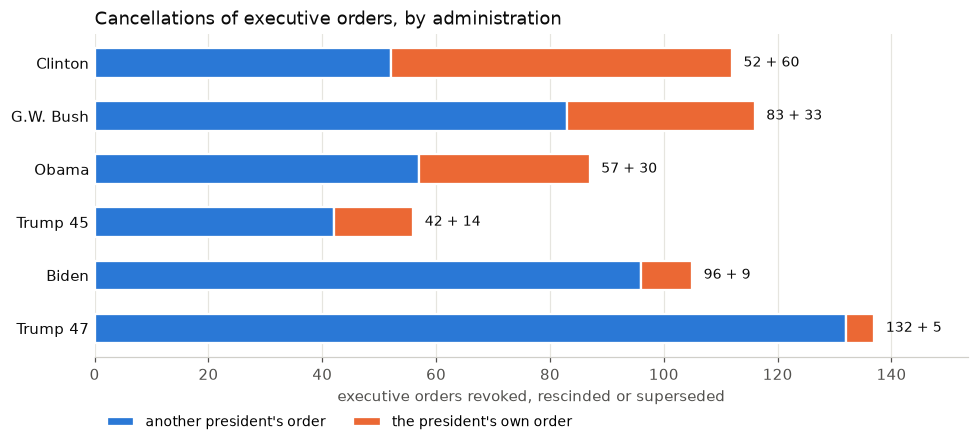

In [10]:
# Series colours: categorical slots 1 and 2 of the reference palette, validated as an
# adjacent pair (CVD dE >= 8, normal-vision dE >= 15).
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"

fig, ax = plt.subplots(figsize=(9, 4.2))
rows = by_actor[::-1]  # chronological top to bottom
y = range(len(rows))
ax.barh(y, rows.prior_president, height=0.55, color=BLUE, label="another president's order",
        edgecolor="white", linewidth=1.5)
ax.barh(y, rows.own, height=0.55, left=rows.prior_president, color=ORANGE,
        label="the president's own order", edgecolor="white", linewidth=1.5)
for i, (prior, own) in enumerate(zip(rows.prior_president, rows.own)):
    ax.text(prior + own + 2, i, f"{int(prior)} + {int(own)}", va="center", fontsize=9, color=INK)
ax.set_yticks(list(y), rows.index)
ax.set_xlabel("executive orders revoked, rescinded or superseded", color=MUTED)
ax.set_title("Cancellations of executive orders, by administration", loc="left", fontsize=12, color=INK)
ax.set_xlim(0, (rows.prior_president + rows.own).max() * 1.12)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, -0.14), ncol=2, fontsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d0cfc9")
ax.tick_params(axis="y", length=0, colors=INK)
ax.tick_params(axis="x", colors=MUTED)
ax.xaxis.grid(True, color="#e6e5df", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Caveats that apply to these numbers.**

- The Federal Register is the authoritative source and its disposition notes are the
  bulk of the edge set. The model's additions are precision-checked (every quote is
  verified) but recall was never measured, so an administration's count is a floor.
- Cancelling *in part* counts as a cancellation. So does `supersedes`.
- Memoranda, proclamations and orders the source names without a number are excluded.
  For the model's edges that is most of what it found: it often cited a section or a
  memorandum rather than an EO number.
- Attribution by EO number for pre-1994 targets rests on the published first-order
  number of each president. A wrong boundary would move a few edges between adjacent
  presidents, never between the "prior" and "own" columns.

### Which agencies did each administration lean on?

**How an agency is counted.** Through the `agency_taskings` view, which resolves the
name each order used to a canonical agency (Secretary of the Treasury and Department
of the Treasury are one institution; Department of War is Defense across the 2025
rename). An agency is credited once per order it appears in, however many times that
order tasks it — the view unions agency taskings with deadline responsibilities, and
30% of (agency, order) pairs appear in both. `collective` ("all agencies") and
`generic` (a bare "Task Force" that means a body created inside its own order) are
excluded, because neither is an entity that spans orders.

**The measure is a share of the administration's orders**, so terms of different
lengths compare. Trump is split into two terms, using the `administration()` helper
from the previous section.

**What a share means.** "The model extracted a tasking of Treasury from 30% of
Biden's orders." Recall was never measured, so an agency's absence from an order is
not evidence the order did not task it, and every share is a floor.

In [11]:
taskings = q("""
SELECT canonical_name, kind, document_number, president, signing_date
FROM agency_taskings
WHERE kind NOT IN ('collective', 'generic')
""")
taskings["actor"] = [administration(p, d) for p, d in zip(taskings.president, taskings.signing_date)]
# One credit per (agency, order): the view records the same obligation twice when an
# order both tasks an agency and sets it a deadline.
pairs = taskings.drop_duplicates(["canonical_name", "document_number"])

orders_all = q("SELECT document_number, president, signing_date FROM orders")
orders_all["actor"] = [administration(p, d) for p, d in zip(orders_all.president, orders_all.signing_date)]
orders_per_actor = orders_all.actor.value_counts().reindex(ADMINS)

breadth = pd.DataFrame({
    "orders": orders_per_actor,
    "orders_with_a_tasking": pairs.groupby("actor").document_number.nunique().reindex(ADMINS),
    "distinct_agencies": pairs.groupby("actor").canonical_name.nunique().reindex(ADMINS),
})
breadth["share_with_a_tasking"] = (breadth.orders_with_a_tasking / breadth.orders * 100).round(0).astype(int)
breadth["agencies_per_tasking_order"] = (pairs.groupby("actor").size().reindex(ADMINS) / breadth.orders_with_a_tasking).round(1)
breadth

,orders,orders_with_a_tasking,distinct_agencies,share_with_a_tasking,agencies_per_tasking_order
actor,,,,,
Clinton,308,152,139,49,2.0
G.W. Bush,291,139,102,48,1.8
Obama,276,173,172,63,2.1
Trump 45,220,170,125,77,2.3
Biden,162,113,103,70,3.2
Trump 47,277,247,144,89,2.7


The top eight agencies of each administration, by the number of its orders that task
them. The number in brackets is that count.

In [12]:
SHORT_AGENCY = {
    "Department of Health and Human Services": "HHS", "Department of Homeland Security": "DHS",
    "Office of Management and Budget": "OMB", "Office of Personnel Management": "OPM",
    "Executive Office of the President": "EOP", "Environmental Protection Agency": "EPA",
    "Office of Science and Technology Policy": "OSTP", "General Services Administration": "GSA",
}


def short_agency(name: str) -> str:
    if name in SHORT_AGENCY:
        return SHORT_AGENCY[name]
    for prefix in ("Department of the ", "Department of "):
        if name.startswith(prefix):
            return name[len(prefix):]
    return name


counts = pairs.groupby(["actor", "canonical_name"]).size().rename("orders").reset_index()
top8 = {}
for actor in ADMINS:
    rows = counts[counts.actor == actor].nlargest(8, "orders")
    top8[actor] = [f"{short_agency(n)} ({o})" for n, o in zip(rows.canonical_name, rows.orders)]
pd.DataFrame(top8, index=range(1, 9))

,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47
1,Defense (16),Treasury (20),Treasury (30),Treasury (31),OMB (28),Justice (58)
2,Treasury (16),The President (16),State (15),HHS (25),HHS (24),DHS (49)
3,The President (16),Defense (14),OMB (15),State (25),DHS (23),Commerce (46)
4,Justice (11),State (13),The President (15),DHS (24),Defense (18),State (39)
5,OPM (11),DHS (11),EOP (12),Commerce (20),Treasury (18),Defense (33)
6,Commerce (9),HHS (9),HHS (10),Justice (20),State (16),OMB (32)
7,HHS (9),Justice (9),Labor (10),OMB (15),Justice (13),Treasury (29)
8,OMB (9),Commerce (8),Defense (9),OPM (15),Commerce (11),HHS (19)


The same measure as a share of each administration's orders, for the twelve agencies
tasked in the most orders overall. Reading down a column shows an administration's
profile; reading across a row shows an agency's rise or fall.

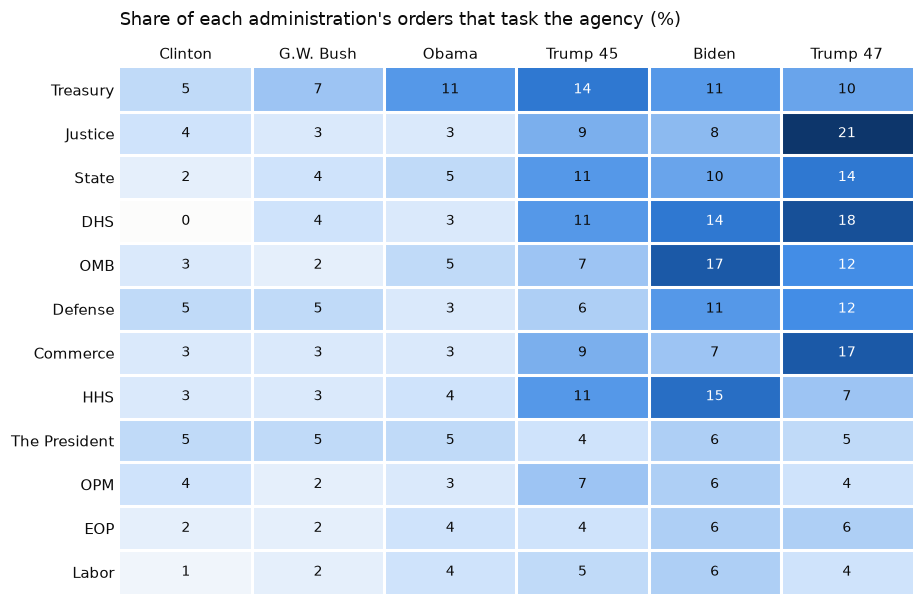

In [13]:
from matplotlib.colors import LinearSegmentedColormap

TOP_N = 12
top_agencies = pairs.canonical_name.value_counts().head(TOP_N).index
share = (counts[counts.canonical_name.isin(top_agencies)]
         .pivot(index="canonical_name", columns="actor", values="orders")
         .reindex(index=top_agencies, columns=ADMINS).fillna(0))
share = (share.div(orders_per_actor, axis=1) * 100).round(0)

# One hue, light to dark: the reference palette's sequential blue ramp.
RAMP = LinearSegmentedColormap.from_list("blue", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])

fig, ax = plt.subplots(figsize=(8.5, 5.6))
im = ax.imshow(share.values, cmap=RAMP, vmin=0, vmax=share.values.max(), aspect="auto")
ax.set_xticks(range(len(ADMINS)), ADMINS)
ax.set_yticks(range(TOP_N), [short_agency(n) for n in share.index])
ax.xaxis.tick_top()
ax.tick_params(length=0, colors=INK)
for i in range(TOP_N):
    for j in range(len(ADMINS)):
        v = share.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                color="white" if v >= 0.55 * share.values.max() else INK)
# 2px surface gaps between cells
ax.set_xticks([x - 0.5 for x in range(1, len(ADMINS))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, TOP_N)], minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
for side in ax.spines.values():
    side.set_visible(False)
ax.set_title("Share of each administration's orders that task the agency (%)",
             loc="left", fontsize=12, color=INK, pad=28)
plt.tight_layout()
plt.show()

**Caveats that apply to these numbers.**

- Shares are floors: recall was never measured, so "tasks DHS in 17% of orders" means
  the model extracted such a tasking from 17%, not that 83% did not task DHS.
- The Department of Homeland Security did not exist until November 2002, so its
  G.W. Bush share covers only part of that term.
- `The President` appears as an agency where an order assigns a duty to the
  President in person, typically appointments. Bodies named after the office
  ("President's Council on ...") are separate entities and are not counted here.
- 18% of agency mentions did not match the alias table and stand as their own
  one-off entities. They are in the breadth figures but never reach a top-eight list,
  which is the point: they are commissions and task forces that appear once.

### Topic mix by administration

**What `primary_topic` is.** One of fourteen subject domains, or `other`, assigned by
the model to each order under prompt v7. It is the dataset's weakest verified field:
on the 20-order gold set the cheap model agreed with hand labels 90% of the time, but
against a frontier model on 36 orders it missed one topic in five, always by defaulting
to `government_administration` or `foreign_policy` where a specific domain applied.
Read the shares below as indicative, and expect `government_administration` to be
somewhat inflated at the expense of the specific domains.

**What `other` is.** A vocabulary gap, not a finding about the orders. On the topic
axis it is 1.8% and its reasons are true one-offs (a millennium commemoration, the
Army–Navy football broadcast). It is kept as its own row rather than dropped.

Shares are of each administration's orders, with Trump split into two terms.

In [14]:
TOPIC_ORDER = q("SELECT primary_topic FROM orders GROUP BY 1 ORDER BY COUNT(*) DESC")["primary_topic"].tolist()
TOPIC_ORDER = [t for t in TOPIC_ORDER if t != "other"] + ["other"]

topics = q("SELECT document_number, president, signing_date, primary_topic FROM orders")
topics["actor"] = [administration(p, d) for p, d in zip(topics.president, topics.signing_date)]

topic_counts = (topics.pivot_table(index="primary_topic", columns="actor", values="document_number", aggfunc="size", fill_value=0)
                      .reindex(index=TOPIC_ORDER, columns=ADMINS, fill_value=0))
topic_share = (topic_counts / topic_counts.sum() * 100).round(1)
topic_share["corpus"] = (topic_counts.sum(axis=1) / topic_counts.values.sum() * 100).round(1)
topic_share

actor,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47,corpus
primary_topic,,,,,,,
government_administration,23.1,35.4,28.3,22.7,25.3,20.2,26.0
energy_and_environment,17.9,9.6,11.2,10.9,8.0,13.7,12.3
foreign_policy,10.1,14.1,14.1,10.5,12.3,7.2,11.3
technology_and_research,9.4,5.8,6.9,10.5,10.5,9.4,8.5
justice_and_law_enforcement,4.9,7.2,7.6,10.9,9.9,11.9,8.5
health,6.2,5.8,5.1,11.4,10.5,5.8,7.0
security_and_defense,6.2,6.2,6.2,2.7,3.7,4.7,5.1
trade,3.9,1.7,4.0,3.2,0.0,11.6,4.4
education,3.6,3.4,2.5,4.1,5.6,5.4,4.0


Each administration's three largest domains, with the share of its orders.

In [15]:
def label(topic: str) -> str:
    return topic.replace("_and_", " & ").replace("_", " ")


top3 = {}
for actor in ADMINS:
    s = topic_share[actor].drop("other").nlargest(3)
    top3[actor] = [f"{label(t)} ({v:.0f}%)" for t, v in s.items()]
pd.DataFrame(top3, index=[1, 2, 3])

,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47
1,government administration (23%),government administration (35%),government administration (28%),government administration (23%),government administration (25%),government administration (20%)
2,energy & environment (18%),foreign policy (14%),foreign policy (14%),health (11%),foreign policy (12%),energy & environment (14%)
3,foreign policy (10%),energy & environment (10%),energy & environment (11%),energy & environment (11%),technology & research (10%),justice & law enforcement (12%)


Where each administration departs from the corpus as a whole: the difference, in
percentage points, between its share of a domain and the all-corpus share. Blue is
above the corpus average, red below; the midpoint is grey so "no difference" reads as
nothing.

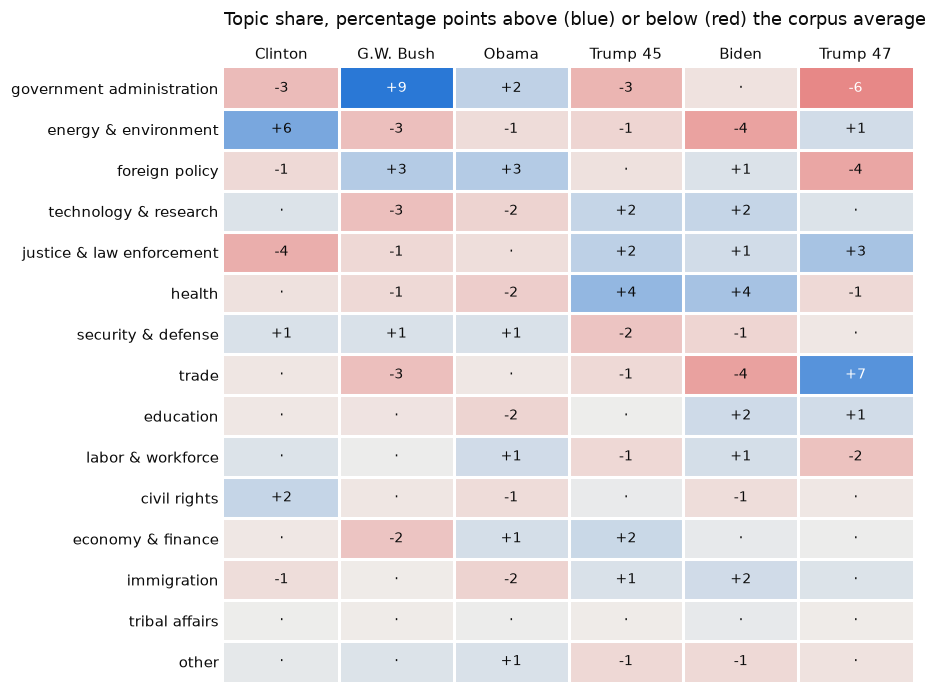

In [16]:
from matplotlib.colors import TwoSlopeNorm

deviation = topic_share[ADMINS].sub(topic_share["corpus"], axis=0)
limit = float(abs(deviation.values).max())

# Diverging: blue (above) <-> neutral grey <-> red (below), from the reference palette.
DIVERGING = LinearSegmentedColormap.from_list("bwr_palette", ["#e34948", "#f0efec", "#2a78d6"])

fig, ax = plt.subplots(figsize=(8.5, 6.4))
ax.imshow(deviation.values, cmap=DIVERGING, norm=TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit), aspect="auto")
ax.set_xticks(range(len(ADMINS)), ADMINS)
ax.set_yticks(range(len(TOPIC_ORDER)), [label(t) for t in TOPIC_ORDER])
ax.xaxis.tick_top()
ax.tick_params(length=0, colors=INK)
for i in range(len(TOPIC_ORDER)):
    for j in range(len(ADMINS)):
        v = deviation.values[i, j]
        ax.text(j, i, f"{v:+.0f}" if abs(v) >= 1 else "·", ha="center", va="center", fontsize=9,
                color="white" if abs(v) >= 0.6 * limit else INK)
ax.set_xticks([x - 0.5 for x in range(1, len(ADMINS))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(TOPIC_ORDER))], minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
for side in ax.spines.values():
    side.set_visible(False)
ax.set_title("Topic share, percentage points above (blue) or below (red) the corpus average",
             loc="left", fontsize=11.5, color=INK, pad=28)
plt.tight_layout()
plt.show()

**Caveats that apply to these numbers.**

- `primary_topic` is the cheap model's reading, and its known bias is toward
  `government_administration`. A frontier re-sweep would move roughly one order in
  five to a more specific domain, which would lower that row and raise others.
- One topic per order. An order that creates a task force on cybersecurity in the
  health sector is one of `technology_and_research` or `health`, not both; secondary
  topics exist for only 192 orders and are not used here.
- Deviations for Biden and Trump 47 rest on 162 and 277 orders, so a difference of a
  point or two is a handful of orders.
- `tribal_affairs` has three orders in the whole corpus; its row is shown for
  completeness and carries no signal.